In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
df = pd.read_csv(r"C:\Users\user\Downloads\ML-Dataset.csv")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   RegionName           400 non-null    object 
 1   CountryName          400 non-null    object 
 2   State                400 non-null    object 
 3   City                 400 non-null    object 
 4   PostalCode           400 non-null    object 
 5   WarehouseAddress     400 non-null    object 
 6   WarehouseName        400 non-null    object 
 7   EmployeeName         400 non-null    object 
 8   EmployeeEmail        400 non-null    object 
 9   EmployeePhone        400 non-null    float64
 10  EmployeeHireDate     400 non-null    object 
 11  EmployeeJobTitle     400 non-null    object 
 12  CategoryName         400 non-null    object 
 13  ProductName          400 non-null    object 
 14  ProductDescription   400 non-null    object 
 15  ProductStandardCost  400 non-null    flo

In [10]:
df.describe()

,EmployeePhone,ProductStandardCost,Profit,ProductListPrice,CustomerCreditLimit,CustomerPhone,OrderItemQuantity,PerUnitPrice,TotalItemQuantity
count,4.000000e+02,400.000000,400.000000,400.000000,400.000000,4.000000e+02,400.000000,400.000000,400.000000
mean,1.300547e+12,1812.654525,189.743700,2002.398800,2033.617500,6.422347e+10,89.240000,839.253100,123.695000
std,3.546644e+12,4297.988742,254.318871,4432.591249,1534.488065,1.871854e+11,34.064253,706.449917,67.438876
min,1.856490e+07,12.630000,0.000000,15.550000,100.000000,4.538500e+04,32.000000,16.990000,0.000000
25%,9.716165e+08,414.160000,59.972500,502.982500,700.000000,3.545837e+09,61.000000,352.982500,92.750000
50%,1.168870e+10,698.320000,134.200000,849.990000,1500.000000,9.800588e+09,85.500000,686.990000,123.000000
75%,2.651186e+10,1671.950000,229.520000,1999.890000,3500.000000,1.812122e+10,118.000000,1055.990000,178.000000
max,1.144160e+13,75410.000000,2770.000000,78180.000000,5000.000000,9.138590e+11,157.000000,4139.000000,353.000000


In [4]:
df.head()

,RegionName,CountryName,State,City,PostalCode,WarehouseAddress,WarehouseName,EmployeeName,EmployeeEmail,EmployeePhone,...,CustomerName,CustomerAddress,CustomerCreditLimit,CustomerEmail,CustomerPhone,Status,OrderDate,OrderItemQuantity,PerUnitPrice,TotalItemQuantity
0,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Summer Payne,summer.payne@example.com,5.151238e+09,...,Flor Stone,2904 S Salina St,5000,flor.stone@raytheon.com,1.317123e+10,Shipped,17-Nov-16,132,469.99,122
1,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Rose Stephens,rose.stephens@example.com,5.151238e+09,...,Lavera Emerson,"5344 Haverford Ave, Philadelphia",5000,lavera.emerson@plainsallamerican.com,1.317123e+10,Shipped,20-Feb-17,124,519.99,123
2,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Annabelle Dunn,annabelle.dunn@example.com,5.151234e+09,...,Fern Head,"1795 Wu Meng, Muang Chonburi",1200,fern.head@usfoods.com,1.812123e+10,Canceled,3-Jan-17,92,800.74,123
3,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Tommy Bailey,tommy.bailey@example.com,5.151235e+09,...,Shyla Ortiz,"Walpurgisstr 69, Munich",2400,shyla.ortiz@abbvie.com,1.317123e+10,Pending,15-Oct-17,128,849.99,124
4,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Blake Cooper,blake.cooper@example.com,5.151235e+09,...,Jeni Levy,"Via Frenzy 6903, Roma",1200,jeni.levy@centene.com,1.812121e+10,Shipped,9-Apr-17,106,109.99,125


In [11]:
df.isnull().sum()

RegionName             0
CountryName            0
State                  0
City                   0
PostalCode             0
WarehouseAddress       0
WarehouseName          0
EmployeeName           0
EmployeeEmail          0
EmployeePhone          0
EmployeeHireDate       0
EmployeeJobTitle       0
CategoryName           0
ProductName            0
ProductDescription     0
ProductStandardCost    0
Profit                 0
ProductListPrice       0
CustomerName           0
CustomerAddress        0
CustomerCreditLimit    0
CustomerEmail          0
CustomerPhone          0
Status                 0
OrderDate              0
OrderItemQuantity      0
PerUnitPrice           0
TotalItemQuantity      0
dtype: int64

In [12]:
Duplicates = df.duplicated().sum()
print("Number of duplicate rows:", Duplicates)

Number of duplicate rows: 0


In [14]:
df["OrderDate"].head(10)

0   2016-11-17
1   2017-02-20
2   2017-01-03
3   2017-10-15
4   2017-04-09
5   2017-08-15
6   2016-12-01
7   2015-04-09
8   2017-05-11
9   2016-12-03
Name: OrderDate, dtype: datetime64[ns]

In [15]:
df["OrderDate"] = pd.to_datetime(
    df["OrderDate"],
    format="%Y-%m-%d"
)

In [16]:
df["OrderDate"].dtype

dtype('<M8[ns]')

In [17]:
df["Year"] = df["OrderDate"].dt.year

In [18]:
df["Month"] = df["OrderDate"].dt.month

In [19]:
df["Day"] = df["OrderDate"].dt.day

In [20]:
df["Month_Name"] = df["OrderDate"].dt.month_name()

In [21]:
df["Quarter"] = df["OrderDate"].dt.quarter

In [22]:
df["Weekday"] = df["OrderDate"].dt.day_name()

In [23]:
df[["OrderDate","Year","Month","Month_Name","Quarter"]].head()

,OrderDate,Year,Month,Month_Name,Quarter
0,2016-11-17,2016,11,November,4
1,2017-02-20,2017,2,February,1
2,2017-01-03,2017,1,January,1
3,2017-10-15,2017,10,October,4
4,2017-04-09,2017,4,April,2


In [24]:
df["Revenue"] = (
    df["PerUnitPrice"] *
    df["OrderItemQuantity"]
)

In [25]:
df[["PerUnitPrice",
    "OrderItemQuantity",
    "Revenue"]].head()

,PerUnitPrice,OrderItemQuantity,Revenue
0,469.99,132,62038.68
1,519.99,124,64478.76
2,800.74,92,73668.08
3,849.99,128,108798.72
4,109.99,106,11658.94


In [26]:
df["Profit Margin (%)"] = (
    (df["Profit"] / df["Revenue"]) * 100
)

In [27]:
df["Revenue per Unit"] = (
    df["Revenue"] /
    df["OrderItemQuantity"]
)

In [28]:
df["Profit per Unit"] = (
    df["Profit"] /
    df["OrderItemQuantity"]
)

In [29]:
df.head()

,RegionName,CountryName,State,City,PostalCode,WarehouseAddress,WarehouseName,EmployeeName,EmployeeEmail,EmployeePhone,...,Year,Month,Day,Month_Name,Quarter,Weekday,Revenue,Profit Margin (%),Revenue per Unit,Profit per Unit
0,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Summer Payne,summer.payne@example.com,5.151238e+09,...,2016,11,17,November,4,Thursday,62038.68,0.875180,469.99,4.113258
1,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Rose Stephens,rose.stephens@example.com,5.151238e+09,...,2017,2,20,February,1,Monday,64478.76,0.695904,519.99,3.618629
2,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Annabelle Dunn,annabelle.dunn@example.com,5.151234e+09,...,2017,1,3,January,1,Tuesday,73668.08,0.849133,800.74,6.799348
3,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Tommy Bailey,tommy.bailey@example.com,5.151235e+09,...,2017,10,15,October,4,Sunday,108798.72,0.377385,849.99,3.207734
4,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Blake Cooper,blake.cooper@example.com,5.151235e+09,...,2017,4,9,April,2,Sunday,11658.94,4.199181,109.99,4.618679


In [30]:
df.to_csv("ML_Dataset_Cleaned.csv", index=False)

# 1. Which product categories generate the highest total profit?

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\user\Downloads\ML-Dataset.csv")

In [7]:
category_profit = (
    df.groupby("CategoryName")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print(category_profit)

CategoryName
CPU             24567.20
Video Card      20036.15
RAM             14671.00
Storage         10888.06
Mother Board     5735.07
Name: Profit, dtype: float64


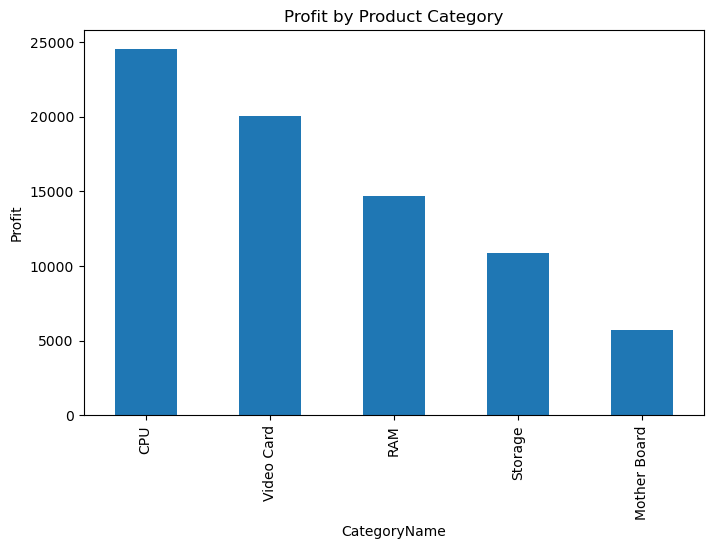

<Figure size 640x480 with 0 Axes>

In [8]:
category_profit.plot(kind="bar", figsize=(8,5))
plt.title("Profit by Product Category")
plt.ylabel("Profit")
plt.show()

plt.savefig("images/Profit_Product_category.png", dpi=300, bbox_inches="tight")

plt.show()

# 2. Which products generate the highest revenue?

ProductName
G.Skill Ripjaws V Series             1063369.12
G.Skill Trident Z                     903422.14
PNY SSD9SC240GMDA-RB                  683691.83
Corsair Dominator Platinum            634488.39
Samsung MZ-V6E500                     550487.00
Crucial CT1050MX300SSD1               472802.75
Kingston Fury (HX316C10FB/8) 8 GB     389855.70
Western Digital WD5000AACS            377972.32
Crucial CT525MX300SSD1                357348.30
Samsung MZ-75E120B/AM                 344872.35
Name: Revenue, dtype: float64


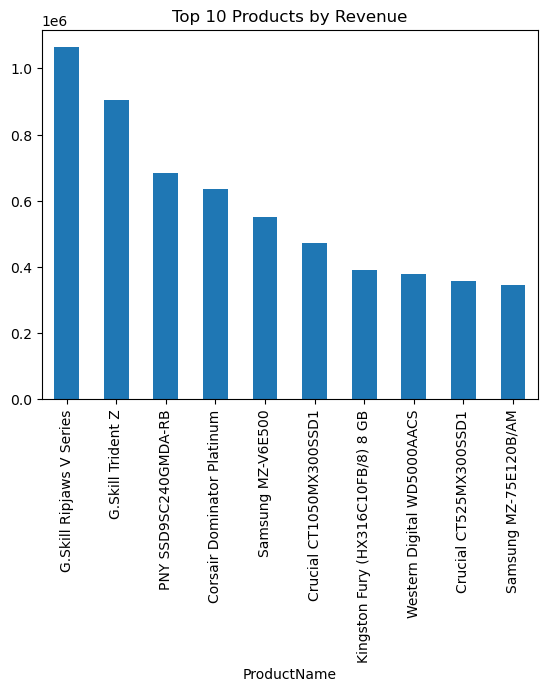

<Figure size 640x480 with 0 Axes>

In [35]:
top_products = (
    df.groupby("ProductName")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

top_products.plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.show()

plt.savefig("images/Top 10 Products by Revenue.png", dpi=300, bbox_inches="tight")

plt.show()

# 3. Which warehouses handle the largest sales volume?

WarehouseName
Mexico City           4850774.35
New Jersy             3821020.40
Sydney                3704306.45
Bombay                3469394.07
Seattle Washington    3184680.56
Toronto               3097190.64
Beijing               2943211.19
San Francisco         2742251.82
Southlake Texas       2707261.23
Name: Revenue, dtype: float64


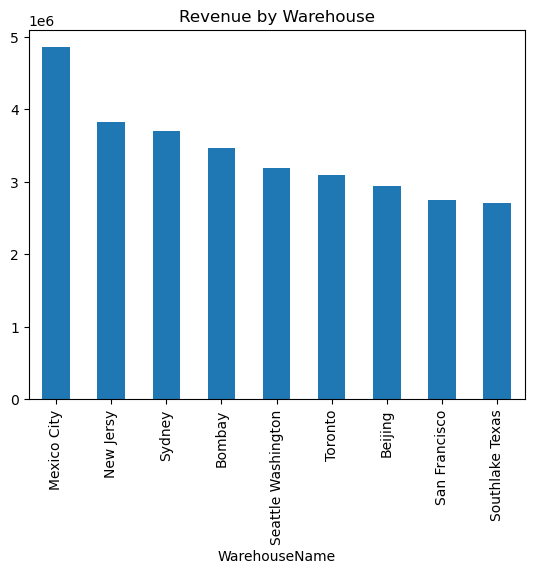

<Figure size 640x480 with 0 Axes>

In [36]:
warehouse_sales = (
    df.groupby("WarehouseName")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(warehouse_sales)

warehouse_sales.plot(kind="bar")
plt.title("Revenue by Warehouse")
plt.show()

plt.savefig("images/Revenue by Warehouse.png", dpi=300, bbox_inches="tight")

plt.show()

# 4. Which employees manage the highest sales?

EmployeeName
Shepard Anita        600155.00
Jackson Maryellen    550487.00
Navathe Kurt         389855.70
Leruth Giovanni      344872.35
LaRotonda William    328038.42
Kian Griffin         323400.00
Newman Richard       307683.51
Clayton Rick         302398.88
Girifalco Evelyn     300139.18
Akinkuolie Sarah     292382.07
Name: Revenue, dtype: float64


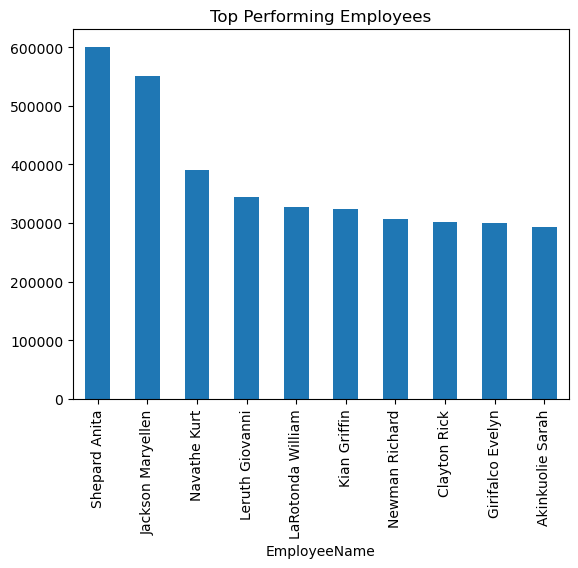

<Figure size 640x480 with 0 Axes>

In [37]:
employee_sales = (
    df.groupby("EmployeeName")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(employee_sales)

employee_sales.plot(kind="bar")
plt.title("Top Performing Employees")
plt.show()

plt.savefig("images/Top Performing Employees.png", dpi=300, bbox_inches="tight")

plt.show()

# 5. Which countries contribute the highest revenue?

CountryName
United States of America    12455214.01
Mexico                       4850774.35
Australia                    3704306.45
India                        3469394.07
Canada                       3097190.64
China                        2943211.19
Name: Revenue, dtype: float64


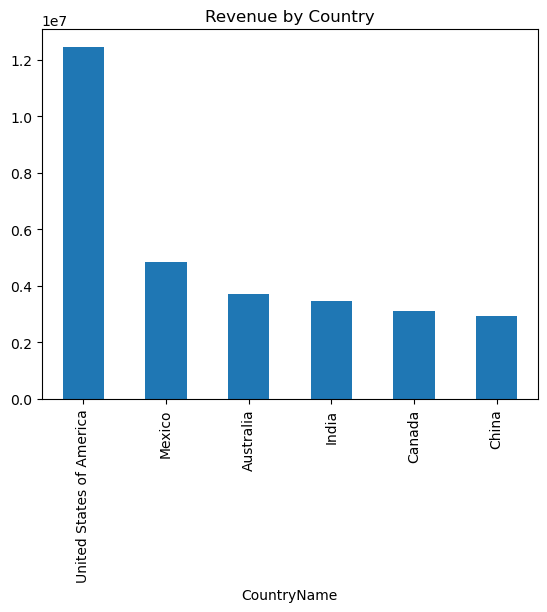

<Figure size 640x480 with 0 Axes>

In [38]:
country_sales = (
    df.groupby("CountryName")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(country_sales)

country_sales.plot(kind="bar")
plt.title("Revenue by Country")
plt.show()

plt.savefig("images/Revenue by Country.png", dpi=300, bbox_inches="tight")

plt.show()

# 6. What are the monthly sales trends?

OrderDate
2013-06     422714.63
2015-04     378220.83
2015-05     565169.36
2015-06     435613.46
2015-10    1097945.92
2015-12     926421.98
2016-02    1402024.96
2016-05     700329.81
2016-06    2150980.94
2016-07     144094.47
2016-08    1328333.52
2016-09    1874581.89
2016-10    2208118.86
2016-11    1632880.33
2016-12    1597785.75
2017-01    1242340.30
2017-02    4573355.78
2017-03    2611744.27
2017-04     938281.17
2017-05     992528.03
2017-06     134097.68
2017-08    1368925.87
2017-09     950200.05
2017-10     450340.30
2017-11     393060.55
Freq: M, Name: Revenue, dtype: float64


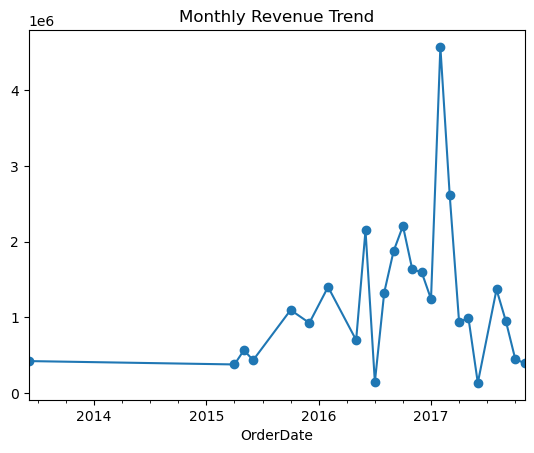

<Figure size 640x480 with 0 Axes>

In [39]:
monthly_sales = (
    df.groupby(df["OrderDate"].dt.to_period("M"))["Revenue"]
      .sum()
)

print(monthly_sales)

monthly_sales.plot(marker="o")
plt.title("Monthly Revenue Trend")
plt.show()

plt.savefig("images/Revenue by Country.png", dpi=300, bbox_inches="tight")

plt.show()

# 7. Which customers contribute the most revenue?

CustomerName
Shields Seffi         600155.00
Bill Stein            550487.00
Daina Combs           389855.70
Mac Mckay             344872.35
Alessandra Estrada    328038.42
Samara Barnett        323400.00
Darron Robertson      307683.51
Glinda Lambert        302398.88
Herman Stokes         300139.18
Reva Fuller           292382.07
Name: Revenue, dtype: float64


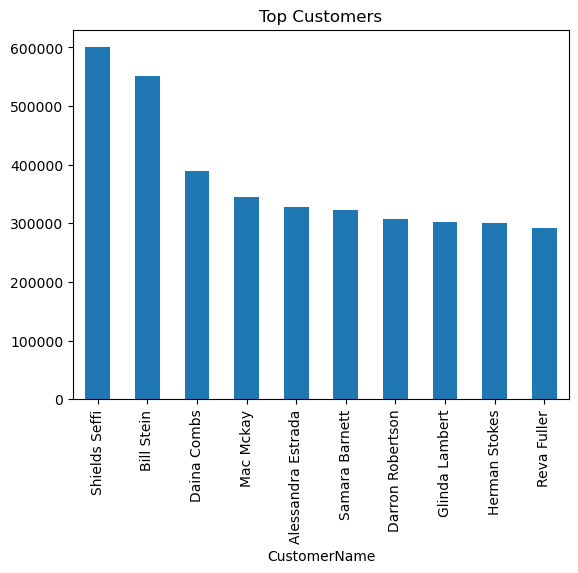

<Figure size 640x480 with 0 Axes>

In [40]:
customer_sales = (
    df.groupby("CustomerName")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(customer_sales)

customer_sales.plot(kind="bar")
plt.title("Top Customers")
plt.show()

plt.savefig("images/Revenue by Country.png", dpi=300, bbox_inches="tight")

plt.show()

# 8. Is there a relationship between product price and profit?

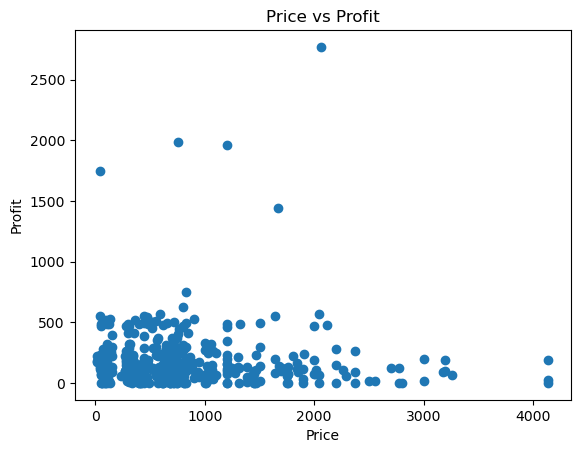

<Figure size 640x480 with 0 Axes>

In [42]:
plt.scatter(df["PerUnitPrice"], df["Profit"])
plt.xlabel("Price")
plt.ylabel("Profit")
plt.title("Price vs Profit")
plt.show()

plt.savefig("images/Revenue by Country.png", dpi=300, bbox_inches="tight")

plt.show()

In [43]:
df[["PerUnitPrice","Profit"]].corr()

,PerUnitPrice,Profit
PerUnitPrice,1.000000,-0.029464
Profit,-0.029464,1.000000


# 9. Which products have the highest sales quantity?

ProductName
G.Skill Ripjaws V Series      1234
G.Skill Trident Z              922
Corsair Dominator Platinum     757
Corsair Vengeance LPX          566
Kingston                       408
Crucial                        374
Asus PRIME X299-A              284
PNY SSD9SC240GMDA-RB           262
Crucial CT1050MX300SSD1        259
Intel Xeon E5-2695 V4          259
Name: OrderItemQuantity, dtype: int64


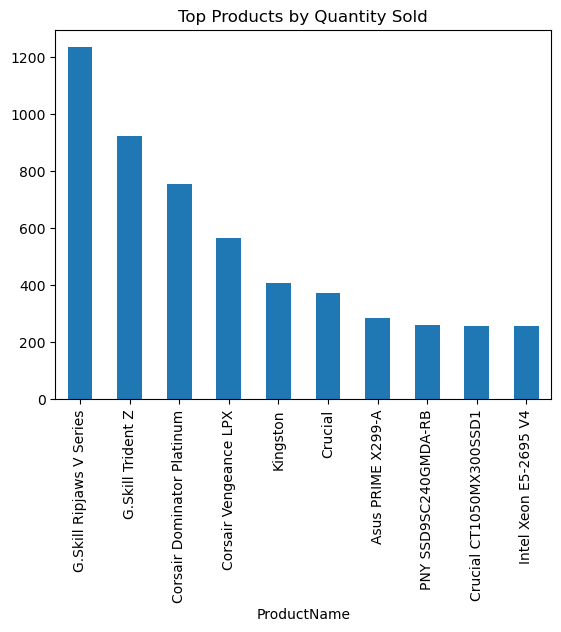

<Figure size 640x480 with 0 Axes>

In [44]:
quantity = (
    df.groupby("ProductName")["OrderItemQuantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(quantity)

quantity.plot(kind="bar")
plt.title("Top Products by Quantity Sold")
plt.show()

plt.savefig("images/Revenue by Country.png", dpi=300, bbox_inches="tight")

plt.show()

# 10. Which customer status contributes the most revenue?

Status
Shipped     14037758.60
Canceled     8390685.96
Pending      8091646.15
Name: Revenue, dtype: float64


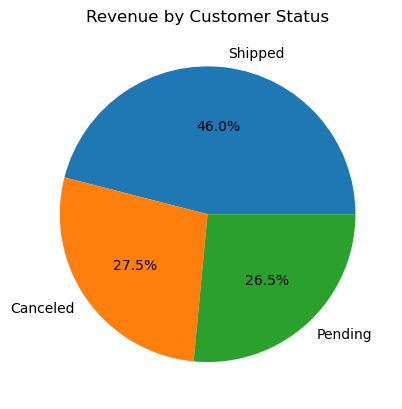

<Figure size 640x480 with 0 Axes>

In [45]:
status_sales = (
    df.groupby("Status")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(status_sales)

status_sales.plot(kind="pie", autopct="%1.1f%%")
plt.title("Revenue by Customer Status")
plt.ylabel("")
plt.show()

plt.savefig("images/Revenue by Country.png", dpi=300, bbox_inches="tight")

plt.show()